# Simulation of a Two-Level Quantum System

## Objective

The goal of this notebook is to implement and study the dynamics of qubit.

This notebook introduces the basics:

- Pauli matrices
- Hamiltonian dynamics
- Schrödinger evolution
- Matrix exponentials

## The Qubit

We all know that a qubit is represented by a state vector in a superposition of states

$$
|\psi\rangle=
\alpha|0\rangle+\beta|1\rangle
$$

where

$$
|\alpha|^2+|\beta|^2=1
$$

But what is bieutiful in quantum mecanics is the specific intrinsic property that allows the states vector to be in those state in what we call spin-1/2.

The evolution of a closed quantum system is governed by the Schrödinger equation

$$
i\frac{d}{dt}|\psi(t)\rangle
=
H|\psi(t)\rangle
$$

For a time-independent Hamiltonian,

$$
U(t)=e^{-iHt}
$$

why we focus on $U(t)$, because this is the engine of our dynamics it is called the propergator

In [120]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

root_path = Path.cwd().parent
sys.path.append(str(root_path / "src"))

from hamiltonians import sigma_x, sigma_y, sigma_z, hamiltonian
from evolution import propagator

print("Sigma X:\n", sigma_x)
print("Sigma Y:\n", sigma_y)
print("Sigma Z:\n", sigma_z)

Sigma X:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Sigma Y:
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
Sigma Z:
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


The Pauli matrices generate the Lie algebra

$$
\mathfrak{su}(2)
$$

They satisfy

$$
[\sigma_x,\sigma_y]
=
2i\sigma_z
$$

and cyclic permutations.

In [121]:
comm = sigma_x @ sigma_y - sigma_y @ sigma_x
print(comm)
assert np.allclose(comm, 2j * sigma_z), "Commutator is incorrect."

[[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]


## Hamiltonian

We consider

$$
H=
\frac{\omega}{2}\sigma_z
$$

This corresponds to a spin-1/2 particle in a magnetic field aligned with the z-axis.

In [122]:
omega = 1.0

H = hamiltonian(omega, 0, 0)

print(H)

[[ 0.5+0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j]]


The corresponding unitary evolution operator is

$$
U(t)=e^{-iHt}
$$

In [123]:
U = propagator(H, t=1.0)

print(U)

[[0.87758256-0.47942554j 0.        +0.j        ]
 [0.        +0.j         0.87758256+0.47942554j]]



In this simulation, we track the time-evolution trajectory of a two-level quantum system (qubit). 

We choose the initial state to be a balanced superposition:
$$\lvert\psi(0)\rangle = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix} = \lvert+\rangle$$

Because squaring the normalization amplitude yields a perfect $50\%$ probability of measuring $\lvert0\rangle$ or $\lvert1\rangle$.

The states evolution is calculated simply by multiplying the propagator by our initial state
$$
\psi(t)=U(t)  \psi_0
$$


In [124]:
psi_0 = np.array([
    1/np.sqrt(2.0),
    1/np.sqrt(2.0)
], dtype=complex)

psi_t = U @ psi_0

print(psi_t)

[0.62054458-0.33900505j 0.62054458+0.33900505j]


The initial state evolves according to the Hamiltonian dynamics generated by H.

In [ ]:
T = 2*np.pi / omega
times = np.linspace(0, T/2, 500)

x = []
y = []
z = []
P0 = []
P1 = []

for t in times:
    U = propagator(H, t)
    psi_t = U @ psi_0
    P0.append(np.abs(psi_t[0])**2)
    P1.append(np.abs(psi_t[1])**2)
    x.append(np.real(psi_t.conj().T @ sigma_x @ psi_t))
    y.append(np.real(psi_t.conj().T @ sigma_y @ psi_t))
    z.append(np.real(psi_t.conj().T @ sigma_z @ psi_t))

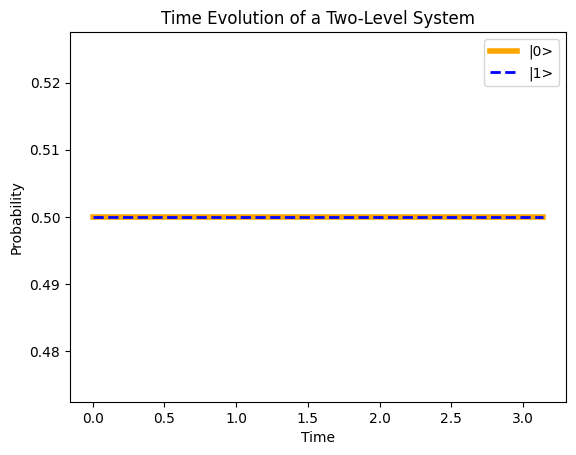

In [126]:
plt.plot(times, P0, label="|0>", lw=4, color='orange')
plt.plot(times, P1, label="|1>", linestyle='--', lw=2, color='blue')
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Time Evolution of a Two-Level System")
plt.legend()

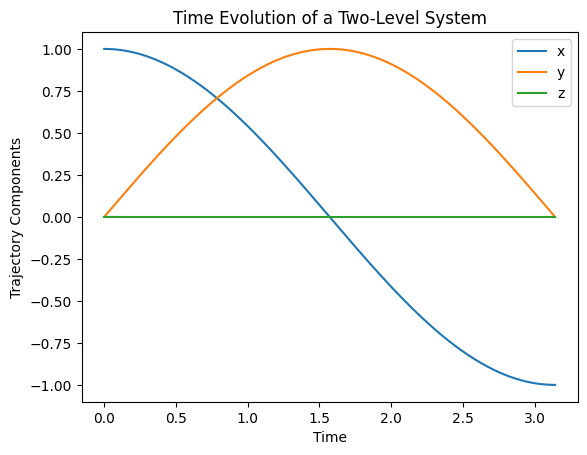

In [127]:
plt.plot(times, x, label="x")
plt.plot(times, y, label="y")
plt.plot(times, z, label="z")
plt.xlabel("Time")
plt.ylabel("Trajectory Components")
plt.title("Time Evolution of a Two-Level System")
plt.legend()

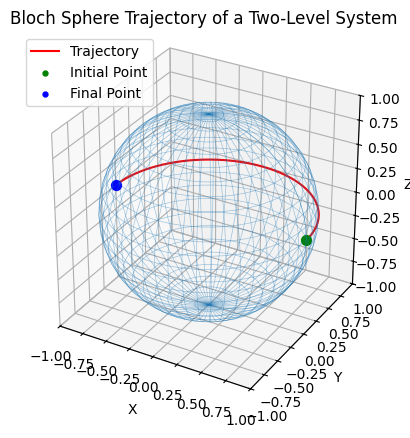

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 25)
XX = np.outer(np.cos(u), np.sin(v))
YY = np.outer(np.sin(u), np.sin(v))
ZZ = np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(XX, YY, ZZ, linewidth=0.5, alpha=0.4)


ax.plot(x, y, z, color='red', label='Trajectory')
ax.scatter(x[0], y[0], z[0], s=50, c='green', label='Initial Point')
ax.scatter(x[-1], y[-1], z[-1], s=50, c='blue', label='Final Point')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Bloch Sphere Trajectory of a Two-Level System')

ax.set_box_aspect([1, 1, 1])
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

ax.legend(loc='upper left', markerscale=0.5)

Although the populations remain constant, the Bloch coordinates exhibit oscillatory behaviour.

This indicates that the state evolves through a continuous change in relative phase.

The drift Hamiltonian therefore induces coherent quantum evolution without population transfer.

## Discussion

In this notebook we implemented a numerical simulation of a single qubit.

We verified:

- Pauli matrix algebra
- Hamiltonian construction
- Unitary evolution
- State propagation

These tools form the basis for quantum control problems.

In future notebooks we will introduce external control fields and investigate the synthesis of quantum gates through pulse engineering.